# Stock Market Trend Analysis: Initial EDA

This notebook explores the cleaned daily OHLCV data for AAPL, MSFT, GOOGL, AMZN, and NVDA. It covers dataset dimensions, date ranges, descriptive statistics, price and volume extremes, and basic time-series visualizations.

This is descriptive EDA only. It does not calculate returns, volatility, moving averages, correlations, or investment recommendations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def load_cleaned_data(ticker):
    path = PROCESSED_DATA_DIR / f"{ticker}_clean.csv"
    data = pd.read_csv(path, index_col="Date", parse_dates=["Date"])
    return data.sort_index()

datasets = {ticker: load_cleaned_data(ticker) for ticker in TICKERS}
print(f"Loaded {len(datasets)} cleaned datasets from {PROCESSED_DATA_DIR}")

## Dataset dimensions and date ranges

In [2]:
dataset_summary = pd.DataFrame(
    [
        {
            "Ticker": ticker,
            "Rows": len(data),
            "Columns": len(data.columns),
            "Start date": data.index.min().date(),
            "End date": data.index.max().date(),
        }
        for ticker, data in datasets.items()
    ]
).set_index("Ticker")
display(dataset_summary)

,Rows,Columns,Start date,End date
Ticker,,,,
AAPL,1255,5,2021-08-16,2026-08-14
MSFT,1255,5,2021-08-16,2026-08-14
GOOGL,1255,5,2021-08-16,2026-08-14
AMZN,1255,5,2021-08-16,2026-08-14
NVDA,1255,5,2021-08-16,2026-08-14


## Descriptive statistics

In [3]:
descriptive_statistics = pd.concat(
    {ticker: data.describe() for ticker, data in datasets.items()},
    names=["Ticker", "Statistic"],
)
display(descriptive_statistics)

Open         High          Low        Close  \
Ticker Statistic                                                       
AAPL   count      1255.000000  1255.000000  1255.000000  1255.000000   
       mean        199.842135   202.054383   197.864327   200.058215   
       std          47.102533    47.541457    46.736749    47.178352   
       min         126.010002   127.769997   124.169998   125.019997   
       25%         163.135002   165.404999   161.135002   163.699997   
       50%         188.399994   189.990005   187.039993   188.610001   
       75%         231.135002   233.175003   228.950005   231.355003   
       max         340.029999   344.570007   337.350006   340.079987   
MSFT   count      1255.000000  1255.000000  1255.000000  1255.000000   
       mean        368.802127   372.339434   365.069482   368.823681   
       std          81.682171    81.907703    81.313028    81.618091   
       min         217.550003   220.410004   213.429993   214.250000   
       25%         299.065002   301.104996   295.494995   299.419998   
       50%         376.369995   380.640015   373.019989   377.429993   
       75%         424.725006   427.855011   420.464996   424.584991   
       max         555.229980   555.450012   540.770020   542.070007   
GOOGL  count      1255.000000  1255.000000  1255.000000  1255.000000   
       mean        174.452185   176.589778   172.422981   174.581138   
       std          76.557810    77.561697    75.551175    76.669624   
       min          85.400002    86.519997    83.339996    83.430000   
       25%         124.990002   126.459999   123.384998   124.742249   
       50%         147.170502   148.559494   145.600494   146.916504   
       75%         185.820000   189.424995   184.885002   186.305000   
       max         399.920013   408.609985   396.359985   402.619995   
AMZN   count      1255.000000  1255.000000  1255.000000  1255.000000   
       mean        172.585626   174.694720   170.351420   172.549323   
       std          48.095030    48.413320    47.696862    48.028813   
       min          82.800003    83.480003    81.430000    81.820000   
       25%         132.055000   133.630005   130.464996   132.025002   
       50%         174.139999   175.927002   172.000000   173.625000   
       75%         213.084999   215.394997   210.955002   212.919998   
       max         281.589996   287.200012   278.000000   284.019989   
NVDA   count      1255.000000  1255.000000  1255.000000  1255.000000   
       mean         89.672072    91.138914    88.049414    89.653071   
       std          67.836953    68.744019    66.762648    67.767294   
       min          10.971000    11.735000    10.813000    11.227000   
       25%          24.365499    25.031500    23.835000    24.429000   
       50%          70.532997    72.184998    69.620003    72.127998   
       75%         142.800003   144.995003   141.045006   142.730003   
       max         229.869995   236.539993   229.300003   235.740005   

                        Volume  
Ticker Statistic                
AAPL   count      1.255000e+03  
       mean       6.459541e+07  
       std        2.861814e+07  
       min        1.791060e+07  
       25%        4.538395e+07  
       50%        5.618200e+07  
       75%        7.639160e+07  
       max        3.186799e+08  
MSFT   count      1.255000e+03  
       mean       2.688598e+07  
       std        1.238594e+07  
       min        5.855900e+06  
       25%        1.920855e+07  
       50%        2.404000e+07  
       75%        3.102650e+07  
       max        1.862016e+08  
GOOGL  count      1.255000e+03  
       mean       3.242842e+07  
       std        1.368668e+07  
       min        9.701400e+06  
       25%        2.374350e+07  
       50%        2.919400e+07  
       75%        3.687415e+07  
       max        1.274901e+08  
AMZN   count      1.255000e+03  
       mean       5.496453e+07  
       std        2.684232e+07  
       min        1.142050e+07  
       25%

## OHLC and trading-volume extremes

In [4]:
extreme_rows = []
for ticker, data in datasets.items():
    highest_close_date = data["Close"].idxmax()
    lowest_close_date = data["Close"].idxmin()
    highest_volume_date = data["Volume"].idxmax()
    lowest_volume_date = data["Volume"].idxmin()
    extreme_rows.append(
        {
            "Ticker": ticker,
            "Highest close": data.loc[highest_close_date, "Close"],
            "Highest close date": highest_close_date.date(),
            "Lowest close": data.loc[lowest_close_date, "Close"],
            "Lowest close date": lowest_close_date.date(),
            "Highest volume": data.loc[highest_volume_date, "Volume"],
            "Highest volume date": highest_volume_date.date(),
            "Lowest volume": data.loc[lowest_volume_date, "Volume"],
            "Lowest volume date": lowest_volume_date.date(),
        }
    )
extremes = pd.DataFrame(extreme_rows).set_index("Ticker")
display(extremes)

,Highest close,Highest close date,Lowest close,Lowest close date,Highest volume,Highest volume date,Lowest volume,Lowest volume date
Ticker,,,,,,,,
AAPL,340.079987,2026-07-28,125.019997,2023-01-05,318679900,2024-09-20,17910600,2025-12-24
MSFT,542.070007,2025-10-28,214.250000,2022-11-03,186201600,2026-06-26,5855900,2025-12-24
GOOGL,402.619995,2026-05-13,83.430000,2022-11-03,127490100,2025-05-07,9701400,2022-11-25
AMZN,284.019989,2026-08-03,81.820000,2022-12-28,272662000,2022-04-29,11420500,2025-12-24
NVDA,235.740005,2026-05-14,11.227000,2022-10-14,1543911000,2023-05-25,65528500,2025-12-24


## Closing price over time

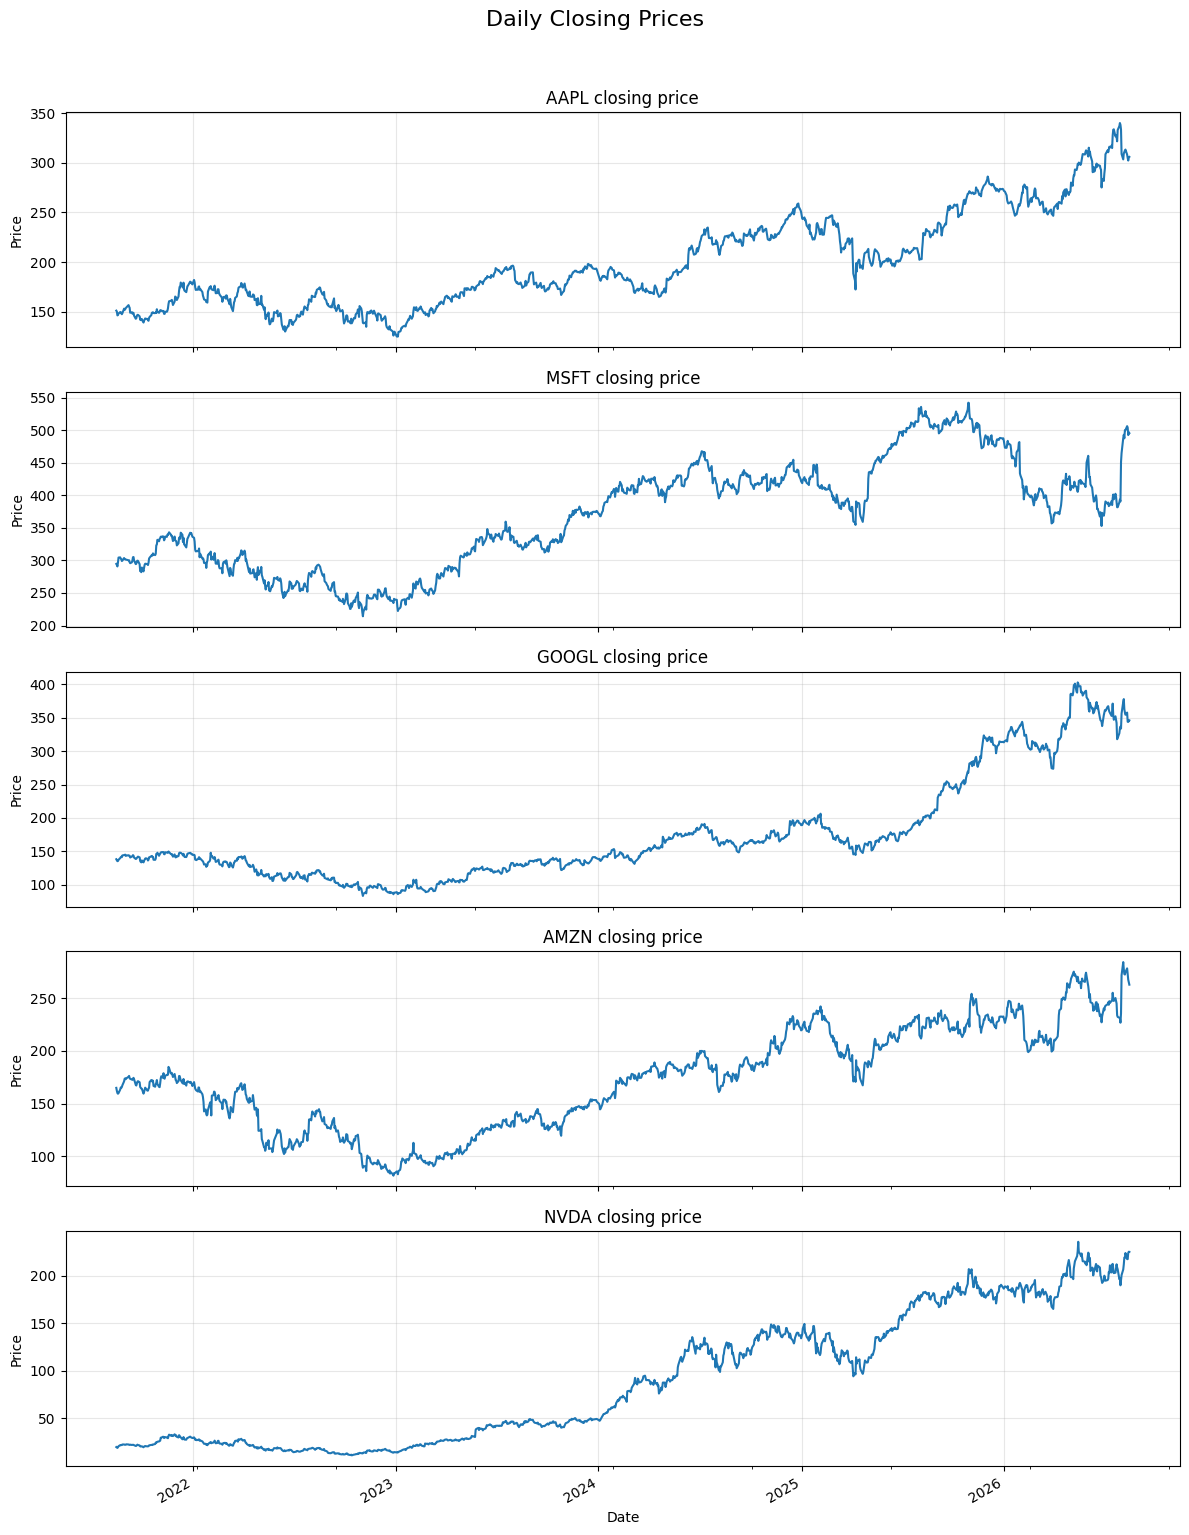

In [5]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 15), sharex=True)
for ax, ticker in zip(axes, TICKERS):
    datasets[ticker]["Close"].plot(ax=ax, title=f"{ticker} closing price")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Date")
fig.suptitle("Daily Closing Prices", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_closing_prices.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

## Trading volume over time

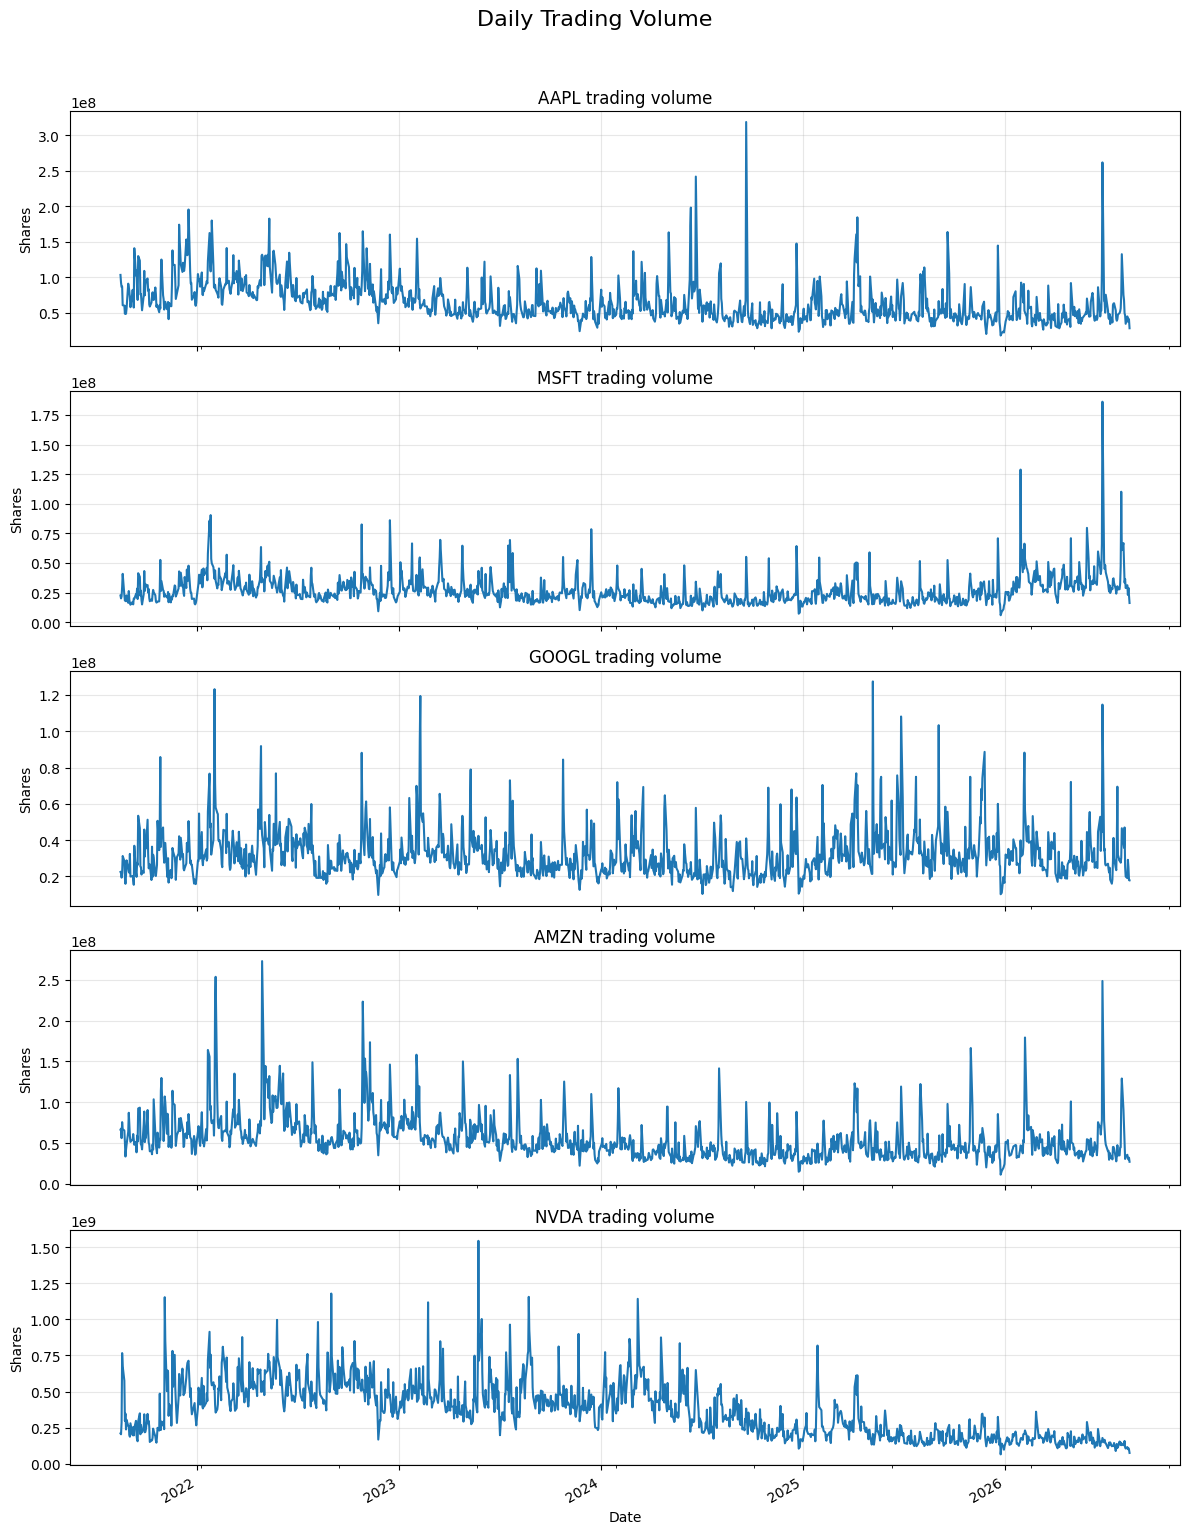

In [6]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 15), sharex=True)
for ax, ticker in zip(axes, TICKERS):
    datasets[ticker]["Volume"].plot(ax=ax, title=f"{ticker} trading volume")
    ax.set_ylabel("Shares")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Date")
fig.suptitle("Daily Trading Volume", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_trading_volume.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

## Absolute closing-price comparison

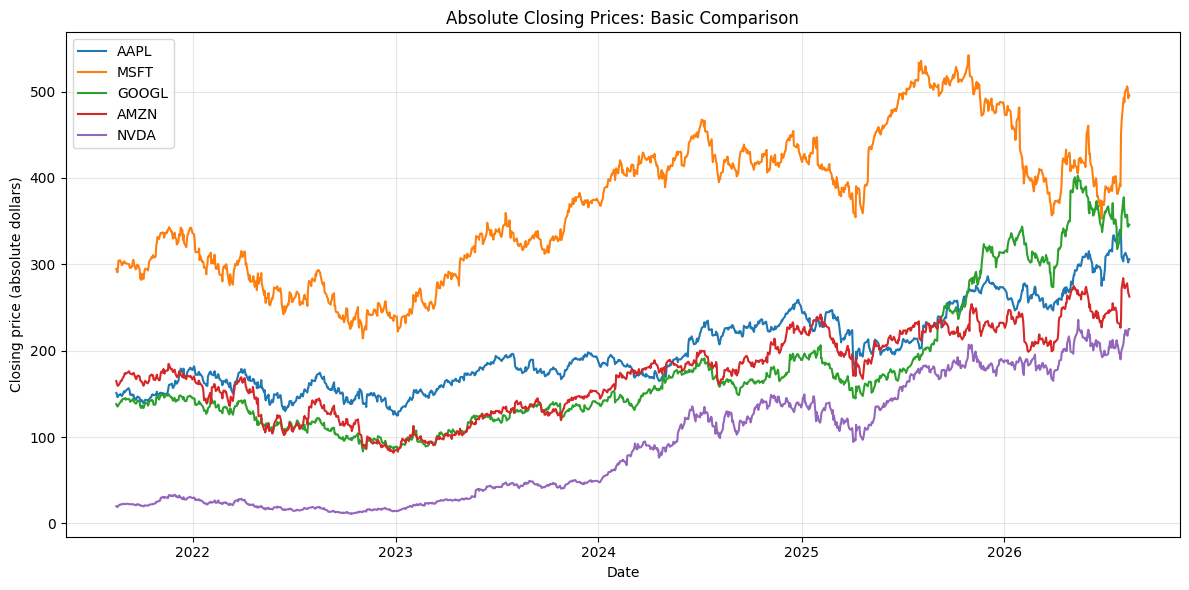

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for ticker, data in datasets.items():
    ax.plot(data.index, data["Close"], label=ticker)
ax.set_title("Absolute Closing Prices: Basic Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (absolute dollars)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_absolute_closing_price_comparison.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

## Initial Observations

The following summary is generated directly from the cleaned data and describes absolute prices and trading volumes only. Absolute closing prices should not be interpreted as investment performance comparisons.

In [8]:
highest_absolute_close = max(
    ((ticker, data["Close"].max()) for ticker, data in datasets.items()),
    key=lambda item: item[1],
)
lowest_absolute_close = min(
    ((ticker, data["Close"].min()) for ticker, data in datasets.items()),
    key=lambda item: item[1],
)
average_volumes = {ticker: data["Volume"].mean() for ticker, data in datasets.items()}
highest_average_volume = max(average_volumes.items(), key=lambda item: item[1])
print(f"Highest observed absolute closing price: {highest_absolute_close[0]} ({highest_absolute_close[1]:.2f})")
print(f"Lowest observed absolute closing price: {lowest_absolute_close[0]} ({lowest_absolute_close[1]:.2f})")
print(f"Highest average daily trading volume: {highest_average_volume[0]} ({highest_average_volume[1]:,.0f} shares)")
print("Visible price and volume patterns can be reviewed in the figures above; no performance or investment conclusion is made.")

Highest observed absolute closing price: MSFT (542.07)
Lowest observed absolute closing price: NVDA (11.23)
Highest average daily trading volume: NVDA (371,449,840 shares)
Visible price and volume patterns can be reviewed in the figures above; no performance or investment conclusion is made.
